In [1]:
#plot grid Reps / Partitions
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider


def plotgRP(images, cols=2, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True,phase=False):

    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    # cols = cols
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3),sharex=True,sharey=True)
    # fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    


    ims=[]
    vs=[]
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    # images=np.array(images)
    for i in range(n):
        if vmax is None:
            v = np.max(np.abs(images[i]))
        else:
            try:
                v = vmax[i]
            except:
                raise SystemError('Vmax expected to be a list of max values for each volume of images')
        # v =v.astype(np.float32)
        vs.append(v)
        # images[i] = images[i].astype(np.float32)
        images[i]=images[i]/v
        ax = axes_flat[i]
        if phase is False:
            im = ax.imshow(abs(images[i][0][0]), cmap=cmap)
        else:
            im = ax.imshow(np.angle(images[i][0][0]), cmap=cmap)
        ims.append(im)
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

    def view_image(r,p,v_min,v_max):
        for i in range(n):
            # v = v_max if vmax is not None else abs(np.max(images[i,...]))
            # ax = axes_flat[i]
            if phase is False:
                ims[i].set_data(abs(images[i][r][p]))
            else:
                ims[i].set_data(np.angle(images[i][r][p]))
            ims[i].set_clim(vmin=v_min,vmax=v_max)
            

        # im.set_data(data / v)
            # im.set_clim(vmin=v_min,vmax=v_max)
        # if titles:
        #     ax.set_title(f"image {i}: {titles[i]}") 

        fig.canvas.draw_idle()

    interact(view_image, p=IntSlider(value=0, min=0, max=len(images[0][0])-1, step=1),
                         r=IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min=FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max=FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


    

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [10]:
#Windowed Partitions/Reps Plot

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def plotRP(images, titles=None, rotate=False, fig_title=None, vmax=None):
    
    if hasattr(images, 'get'): 
        images = images.get()
    images = np.asarray(images)

    if rotate:
        images=np.flip(images,axis=-3)
        images=np.rot90(images,k=-1,axes=(1,2))
        images=np.flip(images,axis=-2)


    

    
    # ---- setup figure ONCE ----
    fig, ax = plt.subplots(figsize=(6, 6))
    if vmax is None:
        v = np.max(np.abs(images))
    else:
        v = vmax
    im = ax.imshow(
        np.abs(images[0][0]) / v,
        cmap='gray',
        animated=False
    )

    ax.set_title(titles[0] if titles else " Reps index:0 , Part index:0 ")
    ax.axis('off')
    if fig_title:
        fig.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        
    def view_image(r, p, v_min,v_max):
        data = np.abs(images[r][p])

        im.set_data(data / v)
        im.set_clim(vmin=v_min,vmax=v_max)
        ax.set_title(titles[p] if titles else f" , Reps index:{r}, Part index:{p}") 

        fig.canvas.draw_idle()

    interact(view_image, r = IntSlider(value=0, min=0, max=len(images)-1, step=1),
                         p = IntSlider(value=0, min=0, max=len(images[0])-1, step=1),
                         v_min = FloatSlider(min=0, max=1, step=0.01, value=0, description='Min (Black)'),
                         v_max = FloatSlider(min=0.01, max=1*3, step=0.01, value=1, description='Max (White)'))


<KeysViewHDF5 ['kdat_01', 'kdat_02', 'ref']>
ref shape before zp (58, 36, 32, 64)
ref shape (58, 48, 120, 240)


interactive(children=(IntSlider(value=0, description='r', max=57), IntSlider(value=0, description='p', max=239…

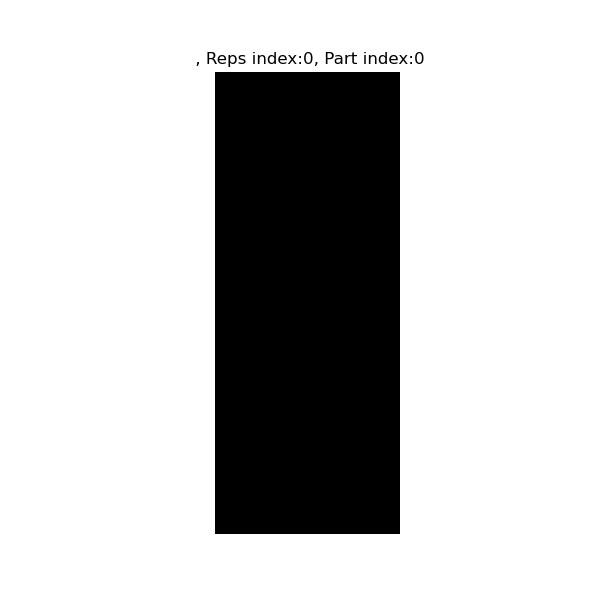

In [33]:
import numpy as np
import h5py
import sigpy as sp
DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_DATA_06052026/'
# DATA_DIR='/home/vault/iwbi/iwbi112h/WM_CEST_DATA/'



sagital=True
# Rep=0 #selected partition 
data=[]
titles=[]

#zf ref images 
imgs=[]
file='CEST_APT_C6/kdat_3D_R26_C58_C6.h5'
# file='CEST_APT_C12/kdat_3D_R26_C58_CAIP12.h5'
# file='CEST_APT_C16/kdat_3D_R26_C58_CAIP16.h5'
# file= 'refs_3D.h5'
with h5py.File(DATA_DIR + file,'r')as f:
    print(f.keys())
    # imgs=np.stack(([f[k][:] for k in f.keys()]),axis=0)

    ref=f['ref'][:]
    print('ref shape before zp',ref.shape)

ref=sp.resize(ref,(58,48,120,240))


print('ref shape',ref.shape)


ref_imgs=sp.ifft(ref,axes=(-3,-2,-1))
abs_ref_imgs=np.abs(ref_imgs)
mask=abs_ref_imgs>(np.max(abs_ref_imgs)*0.005)
# ref_imgs_corr=ref_imgs.copy()
# ref_imgs_corr[:,0:3,:,:]=0 #PE2
# ref_imgs_corr[:,:,:,225::]=0 #RO

if sagital:
    # ref_imgs=ref_imgs.transpose(0,3,2,1)
    # ref_imgs_corr=ref_imgs_corr.transpose(0,3,2,1)
    mask=np.transpose(mask,(-4,-1,-2,-3))
# plotgRP([ref_imgs,ref_imgs_corr],titles=['Ref Image','Ref Image with PE2 and RO cropped'])
plotRP(mask)
# np.sum(mask)